# 04. 学習ダイナミクスと安定化 — なぜ深いネットは学習が難しいか

## この章で分かること

- 深いネットの学習を阻む **勾配消失 / 勾配爆発** の正体
- **初期化**(Xavier / He)がなぜ効くか
- **BatchNorm / LayerNorm / Dropout / 残差接続** が何を安定させるか
- **過学習** と正則化、訓練 vs 検証損失の読み方

ここから PyTorch を使います。02–03 章で逆伝播の中身は理解したので、
本章は「深くしたときに何が壊れ、どう直すか」に集中します。

```{admonition} 核心 — ひとことで
:class: tip
**深いネットの敵は「勾配消失／爆発」と「過学習」。対策は分散を保つ初期化・正規化・残差接続・正則化のセット。**
He/Xavier で各層の分散を保ち、BatchNorm/LayerNorm で崩れを整え直し、残差 $y=x+F(x)$ で勾配を素通しにする。
過学習は train と val の損失の乖離で検出し、Dropout・weight decay・早期終了で抑える。
```

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from nn_textbook import datasets, plotting
from nn_textbook.training import get_device, set_seed

set_seed(0)
# Committed outputs use the CPU for reproducibility. To run on the GPU instead,
# set NN_TEXTBOOK_GPU=1 in the environment before launching Jupyter.
device = get_device() if os.environ.get("NN_TEXTBOOK_GPU") == "1" else torch.device("cpu")
np.set_printoptions(precision=3, suppress=True)
print("torch", torch.__version__, "| device:", device)

torch 2.11.0+cu128 | device: cpu


## 1. Problem — 深くすると勾配が届かない

02 章で、tanh を何段も重ねると勾配が指数的に縮むのを見ました。
同じことが深い MLP でも起きます。各層の活性(隠れ表現)に流れ込む勾配
$\partial L / \partial h_\ell$ のノルムを測ると、初期化次第で
入力側へ向かって勾配が消える / 爆発する様子が見えます。
(層の重みの勾配 $\partial L/\partial W_\ell$ は「前向きの縮小 × 後ろ向きの縮小」が
打ち消し合ってフラットに見えることがあるため、ここでは活性勾配を測ります。)

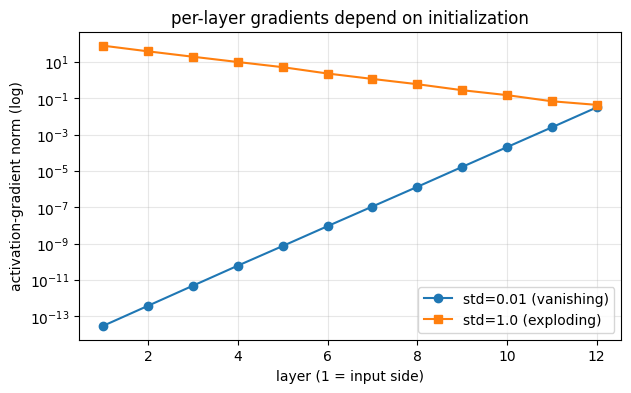

std=0.01: layer1/layer12 = 9.5e-13  (<< 1: vanishing)
std=1.0 : layer1/layer12 = 1.8e+03  (>> 1: exploding)


In [2]:
# A deep MLP: measure the gradient flowing into each layer's ACTIVATIONS
# (dL/dh per layer, captured with backward hooks).
def make_deep_mlp(depth=12, width=64, init_scale=None, activation=nn.Tanh):
    layers = []
    for i in range(depth):
        lin = nn.Linear(width, width)
        if init_scale is not None:
            nn.init.normal_(lin.weight, std=init_scale)
            nn.init.zeros_(lin.bias)
        layers += [lin, activation()]
    return nn.Sequential(*layers)


def activation_grad_norms(model, x, target, act_cls=nn.Tanh):
    grads = []
    for m in model:
        if isinstance(m, act_cls):
            m.register_full_backward_hook(lambda mod, gi, go: grads.append(go[0].norm().item()))
    ((model(x) - target) ** 2).mean().backward()
    return grads[::-1]      # hooks fire output-side first; reverse to layer order


set_seed(0)
x = torch.randn(64, 64)
target = torch.randn(64, 64)

set_seed(0)
norms_small = activation_grad_norms(make_deep_mlp(init_scale=0.01), x, target)
set_seed(0)
norms_big = activation_grad_norms(make_deep_mlp(init_scale=1.0), x, target)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(norms_small) + 1), norms_small, "o-", label="std=0.01 (vanishing)")
ax.semilogy(range(1, len(norms_big) + 1), norms_big, "s-", label="std=1.0 (exploding)")
ax.set_xlabel("layer (1 = input side)"); ax.set_ylabel("activation-gradient norm (log)")
ax.set_title("per-layer gradients depend on initialization")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.show()
print(f"std=0.01: layer1/layer12 = {norms_small[0] / norms_small[-1]:.1e}  (<< 1: vanishing)")
print(f"std=1.0 : layer1/layer12 = {norms_big[0] / norms_big[-1]:.1e}  (>> 1: exploding)")

- 初期化が小さすぎる(std=0.01)→ 勾配が入力側へ向かうほど **消失**
- 大きすぎる(std=1.0)→ 勾配が **爆発**

ちょうどよい初期化が必要だ、と分かります。

## 2. Definition — Xavier と He 初期化

各層で活性と勾配の **分散を保つ** ように重みのスケールを決めます。

- **Xavier (Glorot)**: $\mathrm{Var}(W) = \dfrac{1}{n_\text{in}}$(tanh / sigmoid 向け)
- **He**: $\mathrm{Var}(W) = \dfrac{2}{n_\text{in}}$(ReLU 向け。半分が 0 になる分を補う)

記号: $n_\text{in}$ は入力次元(fan-in)。
正しい初期化なら、深くても勾配ノルムが層をまたいでほぼ一定に保たれます。

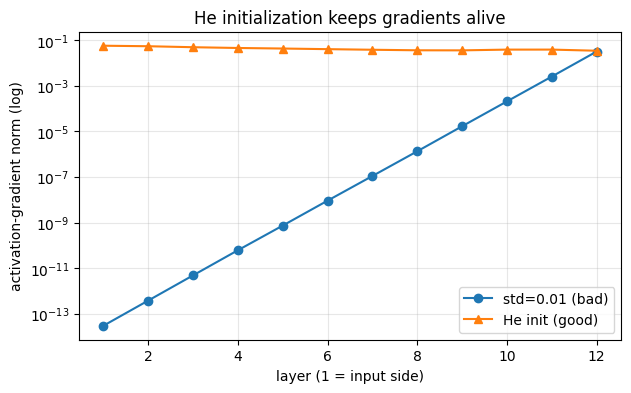

He init: layer1/layer12 = 1.66  (~1: gradients survive)


In [3]:
# He / Xavier keep the gradient norm roughly flat across depth.
def he_mlp(depth=12, width=64, activation=nn.ReLU):
    layers = []
    for _ in range(depth):
        lin = nn.Linear(width, width)
        nn.init.kaiming_normal_(lin.weight, nonlinearity="relu")  # He init
        nn.init.zeros_(lin.bias)
        layers += [lin, activation()]
    return nn.Sequential(*layers)


set_seed(0)
norms_he = activation_grad_norms(he_mlp(), torch.randn(64, 64), torch.randn(64, 64),
                                 act_cls=nn.ReLU)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(norms_small) + 1), norms_small, "o-", label="std=0.01 (bad)")
ax.semilogy(range(1, len(norms_he) + 1), norms_he, "^-", label="He init (good)")
ax.set_xlabel("layer (1 = input side)"); ax.set_ylabel("activation-gradient norm (log)")
ax.set_title("He initialization keeps gradients alive")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.show()
print(f"He init: layer1/layer12 = {norms_he[0] / norms_he[-1]:.2f}  (~1: gradients survive)")

## 3. Visualization — 活性化の分布が層ごとにどうなるか

勾配消失/爆発の根っこは **活性の分布が層を進むほど崩れること** です。
forward 時に各層の出力分布を見ると、悪い初期化では分布が 0 に潰れる / 飽和するのが分かります。

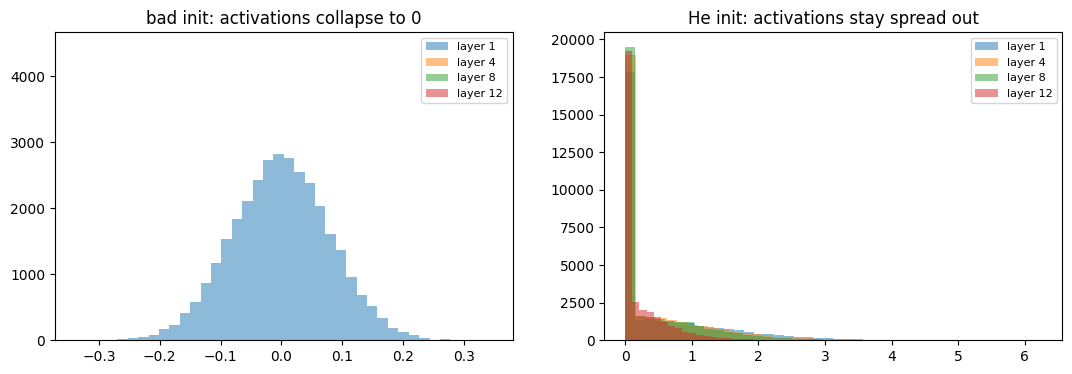

In [4]:
# Activation distributions across layers, good vs bad init (forward hooks).
def collect_activations(model, x):
    acts = []
    hooks = []
    for layer in model:
        if isinstance(layer, (nn.Tanh, nn.ReLU)):
            hooks.append(layer.register_forward_hook(lambda m, i, o: acts.append(o.detach())))
    model(x)
    for h in hooks:
        h.remove()
    return acts


set_seed(0)
x = torch.randn(512, 64)
acts_bad = collect_activations(make_deep_mlp(init_scale=0.01), x)
acts_he = collect_activations(he_mlp(), x)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for layer_idx in [0, 3, 7, 11]:
    axes[0].hist(acts_bad[layer_idx].numpy().ravel(), bins=40, alpha=0.5, label=f"layer {layer_idx + 1}")
    axes[1].hist(acts_he[layer_idx].numpy().ravel(), bins=40, alpha=0.5, label=f"layer {layer_idx + 1}")
axes[0].set_title("bad init: activations collapse to 0"); axes[0].legend(fontsize=8)
axes[1].set_title("He init: activations stay spread out"); axes[1].legend(fontsize=8)
plt.show()

## 4. 正規化 — BatchNorm と LayerNorm

初期化は「最初」を整えるだけ。学習が進むと分布はまた崩れます(internal covariate shift)。
**正規化層** は各ステップで活性を整え直します。

- **BatchNorm**: バッチ方向に平均・分散を正規化。$\hat{x} = \dfrac{x - \mu_\text{batch}}{\sqrt{\sigma^2_\text{batch} + \epsilon}}$、その後スケール・シフト($\gamma, \beta$)を学習。
- **LayerNorm**: 1 サンプル内の特徴方向に正規化。バッチサイズに依存せず、系列モデル(07 章)で標準。

効果を最もはっきり見るため、§1 の「悪い初期化(std=0.01)で勾配が消えた深いネット」に
BatchNorm を入れてみます。初期化が悪いままでも、各層で活性が正規化し直されるので、
学習が立ち上がるはずです。

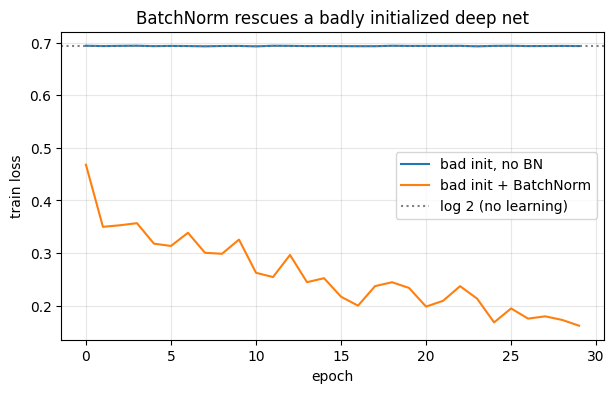

bad init, no BN       : final loss = 0.6938, val acc = 0.475
bad init + BatchNorm  : final loss = 0.1618, val acc = 0.945


In [5]:
# BatchNorm rescues a badly initialized deep net (the failure case from sec. 1).
from torch.utils.data import DataLoader, TensorDataset

from nn_textbook.training import train_torch

Xm, ym = datasets.make_moons_dataset(n=1000, noise=0.2, seed=0)
Xtr, ytr, Xval, yval = datasets.train_val_split(Xm, ym, val_frac=0.2, seed=0)
train_loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(Xval), torch.tensor(yval)), batch_size=64)


def deep_classifier(use_bn=False, depth=8, width=64, init_std=0.01):
    # init_std=0.01 is deliberately BAD (vanishing gradients, as in sec. 1).
    layers = [nn.Linear(2, width)]
    for _ in range(depth):
        lin = nn.Linear(width, width)
        nn.init.normal_(lin.weight, std=init_std)
        nn.init.zeros_(lin.bias)
        layers.append(lin)
        if use_bn:
            layers.append(nn.BatchNorm1d(width))
        layers.append(nn.Tanh())
    layers.append(nn.Linear(width, 2))
    return nn.Sequential(*layers)


histories = {}
for name, use_bn in [("bad init, no BN", False), ("bad init + BatchNorm", True)]:
    set_seed(0)
    model = deep_classifier(use_bn=use_bn)
    opt = torch.optim.SGD(model.parameters(), lr=0.1)
    histories[name] = train_torch(model, train_loader, loss_fn=nn.CrossEntropyLoss(),
                                  optimizer=opt, epochs=30, device=device, val_loader=val_loader)

fig, ax = plt.subplots(figsize=(7, 4))
for name, h in histories.items():
    ax.plot(h["train_loss"], label=name)
ax.axhline(np.log(2), color="gray", ls=":", label="log 2 (no learning)")
ax.set_xlabel("epoch"); ax.set_ylabel("train loss"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("BatchNorm rescues a badly initialized deep net")
plt.show()
for name, h in histories.items():
    print(f"{name:22s}: final loss = {h['train_loss'][-1]:.4f}, val acc = {h['val_acc'][-1]:.3f}")

BN なしでは損失が $\log 2 \approx 0.693$(2 クラスの当てずっぽう)に張り付いたまま —
勾配が消えて何も学習できていません。BN を挟むだけで同じ悪い初期化から学習が立ち上がります。
「初期化が完璧でなくても訓練を成立させる」のが正規化層の実用的な価値です。

## 5. 残差接続 — 恒等写像のショートカット

**残差接続 (residual / skip connection)**: 層の出力に入力を足し戻す。

$$
y = x + F(x)
$$

こうすると、勾配が $F$ を通らず **そのまま** 後ろへ流れる経路ができ($\partial y/\partial x = I + \partial F/\partial x$)、
深くしても勾配が消えにくくなります。ResNet・Transformer の心臓部です。

非常に深いネットで、残差の有無による勾配の届き方を比べます。

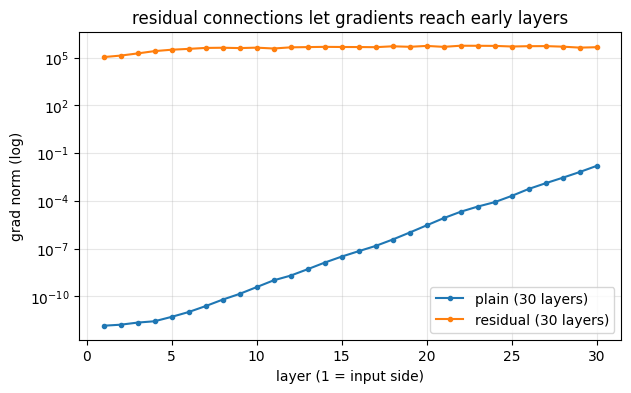

In [6]:
# Residual connections keep the input-side gradient from vanishing in very deep nets.
class DeepNet(nn.Module):
    def __init__(self, depth=30, width=64, residual=False):
        super().__init__()
        self.residual = residual
        self.blocks = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.act = nn.ReLU()

    def forward(self, x):
        for blk in self.blocks:
            out = self.act(blk(x))
            x = x + out if self.residual else out
        return x


set_seed(0)
x = torch.randn(64, 64)
target = torch.randn(64, 64)
grads = {}
for name, res in [("plain (30 layers)", False), ("residual (30 layers)", True)]:
    set_seed(0)
    net = DeepNet(residual=res)
    out = net(x)
    loss = ((out - target) ** 2).mean()
    net.zero_grad(); loss.backward()
    grads[name] = [b.weight.grad.norm().item() for b in net.blocks]

fig, ax = plt.subplots(figsize=(7, 4))
for name, g in grads.items():
    ax.semilogy(range(1, len(g) + 1), g, "o-", ms=3, label=name)
ax.set_xlabel("layer (1 = input side)"); ax.set_ylabel("grad norm (log)")
ax.set_title("residual connections let gradients reach early layers")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.show()

## 6. Dropout と過学習

**過学習**: 訓練データに合わせすぎて、未知データで性能が落ちること。
訓練損失は下がり続けるのに検証損失が上がり始めたら、その兆候です。

**Dropout**: 訓練時に各ニューロンをランダムに $p$ の確率で 0 にする。
特定ニューロンへの依存を防ぎ、正則化として働きます(推論時は全ニューロンを使う)。

Fashion-MNIST の小さなサブセットで、わざと過学習させ、Dropout の効果を見ます。

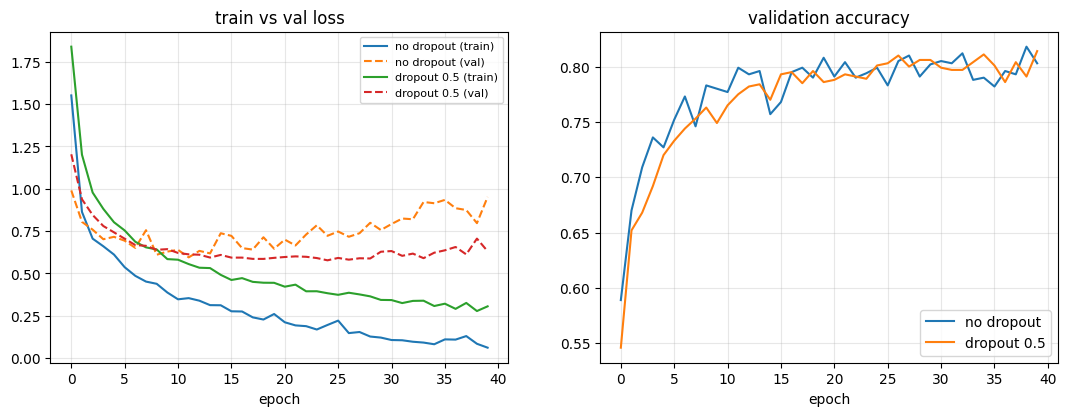

In [7]:
# Overfit a small Fashion-MNIST subset, then see Dropout close the train/val gap.
fm_train = datasets.load_fashion_mnist(train=True, n=1500, seed=0)
fm_val = datasets.load_fashion_mnist(train=False, n=1000, seed=0)


def to_xy(ds):
    xs = torch.stack([img for img, _ in ds]).reshape(len(ds), -1)   # (N, 784)
    ys = torch.tensor([label for _, label in ds])
    return xs, ys


Xtr_i, ytr_i = to_xy(fm_train)
Xval_i, yval_i = to_xy(fm_val)
tr_loader = DataLoader(TensorDataset(Xtr_i, ytr_i), batch_size=64, shuffle=True)
va_loader = DataLoader(TensorDataset(Xval_i, yval_i), batch_size=128)


def fmnist_mlp(dropout=0.0):
    return nn.Sequential(
        nn.Linear(784, 256), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(256, 256), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(256, 10),
    )


hist_over = {}
for name, p in [("no dropout", 0.0), ("dropout 0.5", 0.5)]:
    set_seed(0)
    model = fmnist_mlp(dropout=p)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist_over[name] = train_torch(model, tr_loader, loss_fn=nn.CrossEntropyLoss(),
                                  optimizer=opt, epochs=40, device=device, val_loader=va_loader)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for name, h in hist_over.items():
    axes[0].plot(h["train_loss"], label=f"{name} (train)")
    axes[0].plot(h["val_loss"], "--", label=f"{name} (val)")
    axes[1].plot(h["val_acc"], label=name)
axes[0].set_title("train vs val loss"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[1].set_title("validation accuracy"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3); axes[1].legend()
plt.show()

### ▶ 触って確かめる — 検証損失で過学習を見る

スライダーでエポックを進めると、2 設定の**検証損失**が描かれていきます。Dropout なしは途中から検証損失が上向き（過学習）、
Dropout ありは低く保たれる — 「訓練損失だけ見てはいけない」を動かして確認できます（静的 HTML でも動作）。

In [8]:
# Reveal validation loss over epochs: dropout keeps it from rising (less overfit).
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = plotting.plotly_training_curves(
    list(hist_over.values()), list(hist_over.keys()),
    key="val_loss", title="検証損失：Dropout が過学習を抑える", slider_name="epoch",
)
fig.show()

Dropout なしでは訓練損失だけ下がって検証損失が開いていきます(過学習)。
Dropout を入れると訓練・検証のギャップが縮み、検証精度が改善します。

## 7. 損失地形と最適化の軌道

最適化を「損失の地形を下る」イメージで見ます。
2 次元のパラメータ空間で、SGD と Adam の軌道を比べます。
Adam は勾配の moving average と各次元のスケーリングで、谷を効率よく下ります。

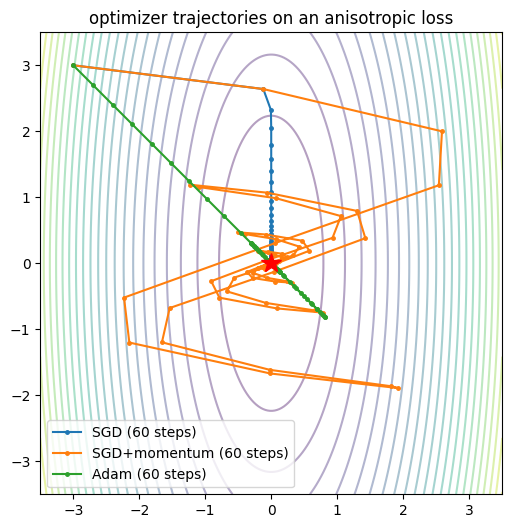

In [9]:
# Optimizer trajectories on a curved 2-D loss surface (anisotropic bowl).
def loss_surface(w):
    return 0.5 * (w[..., 0] ** 2 * 8 + w[..., 1] ** 2)   # steep in x, shallow in y


def run_optimizer(opt_cls, steps=60, **kw):
    w = torch.tensor([-3.0, 3.0], requires_grad=True)
    opt = opt_cls([w], **kw)
    path = [w.detach().clone().numpy()]
    for _ in range(steps):
        opt.zero_grad()
        loss = loss_surface(w)
        loss.backward()
        opt.step()
        path.append(w.detach().clone().numpy())
    return np.array(path)


paths = {
    "SGD": run_optimizer(torch.optim.SGD, lr=0.12),
    "SGD+momentum": run_optimizer(torch.optim.SGD, lr=0.12, momentum=0.9),
    "Adam": run_optimizer(torch.optim.Adam, lr=0.3),
}

gx, gy = np.meshgrid(np.linspace(-3.5, 3.5, 200), np.linspace(-3.5, 3.5, 200))
grid = np.stack([gx, gy], axis=-1)
Z = loss_surface(torch.tensor(grid)).numpy()

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(gx, gy, Z, levels=25, alpha=0.4)
for name, p in paths.items():
    ax.plot(p[:, 0], p[:, 1], "o-", ms=2.5, label=f"{name} ({len(p) - 1} steps)")
ax.plot(0, 0, "r*", ms=15)
ax.legend(); ax.set_title("optimizer trajectories on an anisotropic loss")
ax.set_aspect("equal")
plt.show()

SGD は急な方向で振動しがち。momentum と Adam は振動を抑えて速く収束します。

## 8. Failure Mode — まとめ

| 症状 | 原因 | 対処 |
|---|---|---|
| 勾配が消える | 初期化が小さい / 飽和活性 / 深さ | He/Xavier 初期化・残差接続・正規化 |
| 勾配が爆発 | 初期化が大きい / 不安定 | 勾配クリッピング・正規化 |
| 訓練損失が下がらない | 学習率不適・容量不足 | 学習率調整・Adam・容量増 |
| 検証損失が開く(過学習) | 容量過剰 / データ不足 | Dropout・weight decay・早期終了・データ拡張 |

これらは独立ではなく、深いネットでは複数が同時に効きます。
実務では「初期化 + 正規化 + 残差 + 適切な最適化器」をセットで使うのが標準です。

## 9. Application — 現代アーキテクチャはこの集大成

ResNet・Transformer・拡散モデルといった現代の代表的アーキテクチャは、
本章の安定化技術の組み合わせでできています。

- ResNet: 残差接続 + BatchNorm + He 初期化
- Transformer(07 章): 残差接続 + LayerNorm + Adam + 学習率ウォームアップ
- 大規模学習: 勾配クリッピング + 混合精度 + 慎重な初期化

「深くできる」こと自体が、これらの安定化技術の上に立っています。

```{admonition} 実社会では
:class: important
「深くできる」ことは、安定化技術の上に成り立っています。

- ResNet＝残差＋BatchNorm＋He、Transformer＝残差＋LayerNorm＋Adam＋学習率ウォームアップ。
- 大規模学習：勾配クリッピング・混合精度・慎重な初期化が必須。
- 実務のデバッグ順序：まず損失が `log(クラス数)` に張り付く＝学習が立ち上がっていない → 初期化／学習率／正規化を疑う。

新アーキテクチャの設計も、結局はこの章の部品の組み合わせ方の工夫です。
```

## 10. まとめ

- 深いネットの学習を阻むのは **勾配消失 / 爆発**。第一の対策は分散を保つ初期化(Xavier / He)。
- **BatchNorm / LayerNorm** は活性の分布を整え直し、悪い初期化からでも学習を立ち上げる。
- **残差接続** は恒等経路を作り、深くても勾配を素通しにする(ResNet / Transformer の心臓部)。
- **過学習** は train / val 損失の乖離で検出。Dropout・weight decay・早期終了で抑える。
- 学習率は曲率(固有値)との相対で決まる。momentum / Adam は異方的な谷に強い。
- 現代アーキテクチャ = 「初期化 + 正規化 + 残差 + 適切な最適化器」のセット。

## 11. Exercises

1. `make_deep_mlp` の `init_scale` を 0.01〜1.0 で振り、勾配ノルムの傾きがどう変わるか調べよ。
2. ReLU ネットに He でなく Xavier を使うと、活性分布がどう変わるか観察せよ。
3. BatchNorm の代わりに LayerNorm を deep tanh 分類器に入れ、収束を比較せよ。
4. Fashion-MNIST 過学習実験で weight decay(`Adam(..., weight_decay=1e-3)`)を試し、
   Dropout と効果を比べよ。
5. 残差接続の `DeepNet` で depth を 10 / 30 / 60 と変え、勾配の届き方を比較せよ。
6. (発展)最適化器の軌道で、損失の異方性(`w[...,0]**2 * 8` の係数)を変え、
   SGD が振動し始める学習率の閾値を調べよ。

## 12. Advanced Notes

**なぜ He は分散 $2/n_\text{in}$ か。** ReLU は入力の半分を 0 にするので、
出力の分散は線形層の半分になります。これを補うために fan-in の逆数を 2 倍します。
tanh/sigmoid は 0 付近で恒等に近く半減がないので Xavier($1/n_\text{in}$)で十分です。

**BatchNorm が効く本当の理由は諸説。** 当初の「internal covariate shift の抑制」説に対し、
「損失地形を滑らかにする(Lipschitz 定数を下げる)」という説明(Santurkar et al. 2018)も有力です。
いずれにせよ、より大きな学習率を安全に使えるようになるのが実用上の利点です。

**BatchNorm の落とし穴。** バッチ統計に依存するので、小バッチや系列・生成モデルでは不安定。
推論時は学習中に蓄えた移動平均を使う(train/eval モードの切り替えが必須)。
これらの理由から Transformer は LayerNorm を使います。

**残差接続と恒等写像。** $y = x + F(x)$ は「$F$ がゼロでも情報が素通りする」初期状態を作ります。
学習は恒等写像からの **差分** $F$ だけを学べばよく、最適化が劇的に楽になります
(ResNet の元論文の主張)。Pre-LN Transformer も同じ原理で安定します。

**Adam の中身。** 勾配の 1 次モーメント($m$)と 2 次モーメント($v$)の移動平均を持ち、
$\theta \leftarrow \theta - \eta\, \hat{m}/(\sqrt{\hat{v}} + \epsilon)$ で更新。
各次元を勾配の大きさで自動スケーリングするので、異方的な損失に強い。
バイアス補正($\hat{m}, \hat{v}$)で初期ステップの過小評価を直しています。

## 活性化関数とその微分(インタラクティブ)

活性化を切り替えて関数と導関数を見比べる。sigmoid・tanh の導関数は入力が大きいと 0 に潰れ、これが深い層での勾配消失の正体になる。

In [10]:
import plotly.io as pio
from nn_textbook import plotting as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = viz.plotly_activations()
fig.show()